# Prediciting Risk Of Smoking, Alcohol And Drug Use Among Adolscents

### Step1- Importing libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

### Step2-Loading data


In [2]:
pupil = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/9366_sdd_pupil_data_archive_2023.csv", low_memory=False)
teacher = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/9366_sdd_teacher_data_archive_2023.csv", low_memory=False)
imd = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/imd.csv", low_memory=False)
lad_to_region = pd.read_csv("C:/Users/Syam7/OneDrive/My project/Final Data/LAD19_RGN19_EN_LU.csv", low_memory=False)

#pupil = pd.read_csv("/content/9366_sdd_pupil_data_archive_2023.csv", low_memory=False)
#teacher = pd.read_csv("/content/9366_sdd_teacher_data_archive_2023.csv", low_memory=False)
#imd = pd.read_csv("/content/imd.csv", low_memory=False)
#lad_to_region = pd.read_csv("/content/LAD19_RGN19_EN_LU.csv", low_memory=False)

print("Datasets loaded successfully:")
print(f"Pupil shape   → {pupil.shape}")
print(f"Teacher shape → {teacher.shape}")
print(f"IMD shape     → {imd.shape}")

Datasets loaded successfully:
Pupil shape   → (17466, 657)
Teacher shape → (89, 64)
IMD shape     → (32844, 57)


### Step3 - Cleaning and standardisation of pupil data


In [3]:
# Standardize column names
pupil.columns = pupil.columns.str.strip()

# Renaming behavoural columns to readable

pupil["Smoking"] = pupil["dcgevr"].replace({2: 0, 1: 1})   # 1=yes, 2=no
pupil["Alcohol"] = pupil["alevr"].replace({2: 0, 1: 1})    # 1=yes, 2=no
pupil["Drugs"]   = pupil["ddgany"].replace({0: 0, 1: 1})   # Already binary

# Converting missing/refused values to NaN
missing_codes = [-1, -7, -8, -9]

pupil["Smoking"] = pupil["Smoking"].where(~pupil["dcgevr"].isin(missing_codes))
pupil["Alcohol"] = pupil["Alcohol"].where(~pupil["alevr"].isin(missing_codes))
pupil["Drugs"]   = pupil["Drugs"].where(~pupil["ddgany"].isin(missing_codes))

# Removing missing rows
pupil_clean = pupil.dropna(subset=["Smoking", "Alcohol", "Drugs"]).copy()

print(pupil_clean[["Smoking","Alcohol","Drugs"]].mean())

# Behaviour columns
beh_cols = ["Smoking", "Alcohol", "Drugs"]


Smoking    0.099005
Alcohol    0.351394
Drugs      0.122235
dtype: float64


### Step4-Detecting and cleaning Age/gender columns


In [4]:
# Clean Age
if "age1115" in pupil_clean.columns:
    pupil_clean["age_clean"] = pd.to_numeric(pupil_clean["age1115"], errors="coerce")
    pupil_clean.loc[~pupil_clean["age_clean"].between(11, 15), "age_clean"] = np.nan

# --- Clean Gender ---
gender_map = {1: "Male", 2: "Female", 3: "Other", 5: "Prefer not to say"}
if "dgender" in pupil_clean.columns:
    pupil_clean["gender_label"] = pupil_clean["dgender"].map(gender_map).fillna("Unknown")

# Keep only the final cleaned pupil columns
keep_cols = ["pseudo_pupilid", "age_clean", "gender_label"] + beh_cols
pupil_clean = pupil_clean[keep_cols]




### Ethnicity column cleaning and Mapping

In [5]:
# ----- Ethnicity mapping (from pupil) -----
eth_map = {1:"White", 2:"Mixed", 3:"Asian", 4:"Black", 5:"Other"}

# Clean values and map
pupil["ethnicity_5cat"] = (
    pupil["ethnicgp5"]
    .replace({-7: None, -9: None})
    .map(eth_map)
    .fillna("Unknown")
)

# Add to pupil_clean
pupil_clean["ethnicity"] = pupil["ethnicity_5cat"]
pupil_clean = pupil_clean[pupil_clean["ethnicity"] != "Unknown"].copy()


# Check unique values
print(pupil_clean["ethnicity"].value_counts(dropna=False))
print("pupil_clean:", pupil_clean.shape)

ethnicity
White    10187
Asian     1716
Black     1130
Mixed      845
Other      228
Name: count, dtype: int64
pupil_clean: (14106, 7)


### Step5 --Region codes to 'region name' in pupil dataset

In [6]:
if "region" in pupil.columns:
    region_map = {
        1: "North East", 2: "North West", 3: "Yorkshire and The Humber",
        4: "East Midlands", 5: "West Midlands", 6: "East of England",
        7: "London", 8: "South East", 9: "South West"
    }
    pupil_clean["region_name"] = pupil["region"].map(region_map).fillna("Unknown")
else:
    print("Region column missing in pupil dataset")
print(pupil_clean["region_name"].value_counts(dropna=False))


region_name
North West                  3081
South East                  1809
London                      1663
North East                  1663
Yorkshire and The Humber    1562
East of England             1382
West Midlands               1063
South West                   949
East Midlands                934
Name: count, dtype: int64


### Step6 -- Cleaning IMD and Merging Region in Imd

In [7]:
imd.columns = imd.columns.str.strip()
imd.rename(columns={
   "LSOA code (2011)": "lsoa",
   "Index of Multiple Deprivation (IMD) Score": "imd_score",
   "Income Score (rate)": "income_score",
   "Employment Score (rate)": "employment_score",
   "Education, Skills and Training Score": "education_score",
   "Health Deprivation and Disability Score": "health_score",
   "Crime Score": "crime_score",
   "Barriers to Housing and Services Score": "housing_score",
   "Living Environment Score": "living_env_score",
   "Adult Skills Sub-domain Score": "adult_skills_score",
   "Income Deprivation Affecting Children Index (IDACI) Score (rate)": "idaci_score",
   "region": "region_name",
   "Local Authority District name (2019)": "lad_name",

}, inplace=True)

imd_clean = imd.dropna(subset=["imd_score"]).copy()
#  Remove unwanted columns if any exist
unwanted_cols = [
    "Local Authority District code (2019)",
    "LSOA name (2011)",
    "Index of Multiple Deprivation (IMD) Rank",
    "Index of Multiple Deprivation (IMD) Decile"
]
imd.drop(columns=[c for c in unwanted_cols if c in imd.columns], errors="ignore", inplace=True)

#  Drop rows with missing IMD score
imd_clean = imd.dropna(subset=["imd_score"]).copy()

#  Keep only essential IMD columns
keep_cols = [
    "lsoa", "lad_name", "imd_score", "income_score", "employment_score",
    "education_score", "health_score", "crime_score", "housing_score",
    "living_env_score", "adult_skills_score", "idaci_score"
]

imd_clean = imd_clean[keep_cols].copy()

#  Drop duplicates
imd_clean.drop_duplicates(subset=["lsoa"], inplace=True)
#Merging Region in IMD
imd_merged = (
    imd_clean.merge(
        lad_to_region[["LAD19NM", "RGN19NM"]],
        left_on="lad_name",
        right_on="LAD19NM",
        how="left"
    )
    .rename(columns={"RGN19NM": "region"})
    .drop(columns=["LAD19NM"])
)
imd_clean = imd_merged.copy()

display(list(imd_clean.columns))

['lsoa',
 'lad_name',
 'imd_score',
 'income_score',
 'employment_score',
 'education_score',
 'health_score',
 'crime_score',
 'housing_score',
 'living_env_score',
 'adult_skills_score',
 'idaci_score',
 'region']

### Step6a ---Computing Regional_Imd

In [8]:
regional_stats = (
    imd_clean.groupby("region", as_index=False)
             .agg({
                 "imd_score": "mean",
                 "income_score": "mean",
                 "employment_score": "mean",
                 "education_score": "mean",
                 "health_score": "mean",
                 "crime_score": "mean",
                 "housing_score": "mean",
                 "living_env_score": "mean",
                 "adult_skills_score": "mean",
                 "idaci_score": "mean"
             })
)
# LAD-level mean
lad_mean_imd = (
    imd_merged.groupby("lad_name")["imd_score"]
    .mean()
    .reset_index()
)


# Region-level mean
regional_imd = (
    lad_mean_imd.merge(imd_merged[["lad_name", "region"]].drop_duplicates(), on="lad_name")
    .groupby("region")["imd_score"]
    .mean()
    .reset_index()
    .rename(columns={"imd_score": "regional_mean_imd"})
)
print(regional_imd)

region_means = (
    pupil_clean
    .groupby("region_name")[beh_cols]
    .mean()
    .reset_index()
)
region_means = region_means.merge(
    regional_imd,
    left_on="region_name",
    right_on="region",
    how="left"
).drop(columns=["region"])


                     region  regional_mean_imd
0             East Midlands          18.402815
1           East of England          17.010682
2                    London          21.210097
3                North East          29.056214
4                North West          26.565188
5                South East          14.999831
6                South West          17.394064
7             West Midlands          20.605177
8  Yorkshire and The Humber          22.912238


#### Step6b--Aggregating imd and merging imd with pupil data

In [9]:
#  Merge pupil_clean with region-level IMD
pupil_enriched = pupil_clean.merge(
    regional_stats.rename(columns={"region": "region_name"}),
    on="region_name",
    how="left",
    validate="many_to_one"
)
# Save merged output
pupil_enriched.to_csv("pupil_with_regional_imd.csv", index=False)
print("\n Saved merged dataset: pupil_with_regional_imd.csv")
display(list(pupil_enriched.columns))

# creating target variable which is usefukl for EDA and Modelling
pupil_enriched["risk_behaviour"] = (
    (pupil_enriched["Smoking"] == 1) |
    (pupil_enriched["Alcohol"] == 1) |
    (pupil_enriched["Drugs"] == 1)
).astype(int)


 Saved merged dataset: pupil_with_regional_imd.csv


['pseudo_pupilid',
 'age_clean',
 'gender_label',
 'Smoking',
 'Alcohol',
 'Drugs',
 'ethnicity',
 'region_name',
 'imd_score',
 'income_score',
 'employment_score',
 'education_score',
 'health_score',
 'crime_score',
 'housing_score',
 'living_env_score',
 'adult_skills_score',
 'idaci_score']

### Step7 -- EDA

##### 7A DEMOGRAPHIC DISTRIBUTIONS

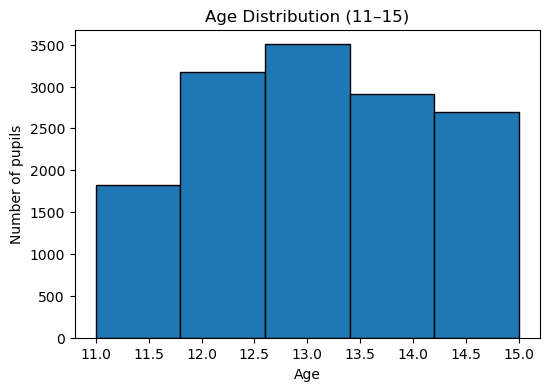

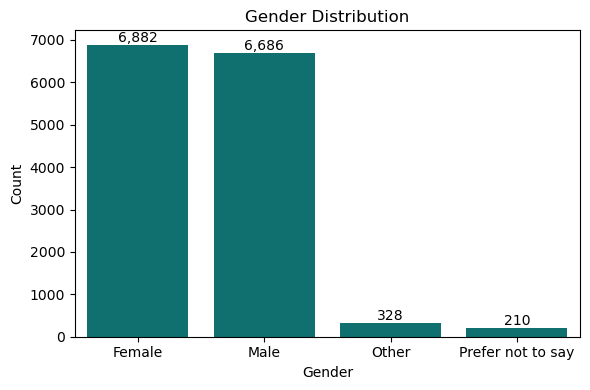

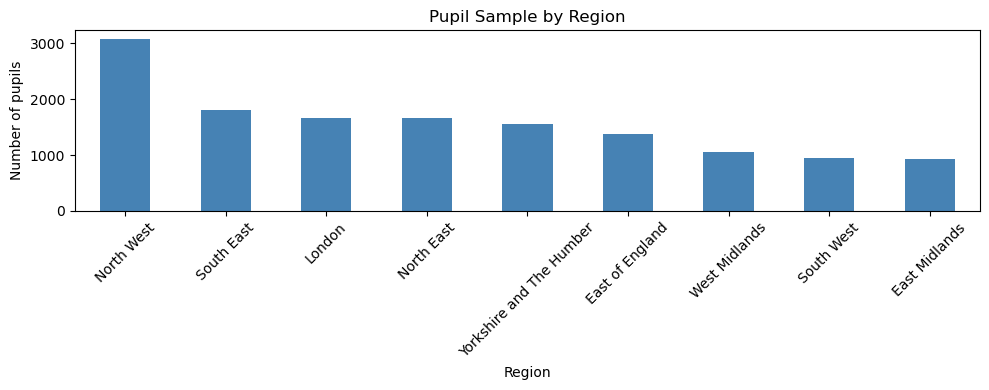

In [10]:
# --- Age ---
plt.figure(figsize=(6,4))
pupil_enriched["age_clean"].dropna().plot(kind="hist", bins=5, edgecolor="black")
plt.title("Age Distribution (11–15)")
plt.xlabel("Age")
plt.ylabel("Number of pupils")
plt.show()

#---Gender---
plt.figure(figsize=(6,4))
ax = sns.countplot(data=pupil_clean, x="gender_label", color="teal")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# Label counts
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
# --- Region ---
plt.figure(figsize=(10,4))
pupil_clean["region_name"].value_counts().plot(kind="bar", color="steelblue", rot=45)
plt.title("Pupil Sample by Region")
plt.xlabel("Region")
plt.ylabel("Number of pupils")
plt.tight_layout()
plt.show()

# 7B BEHAVIOUR PREVALENCE


Overall behaviour prevalence (share of '1's):


Smoking    0.097264
Alcohol    0.357720
Drugs      0.122643
dtype: float64

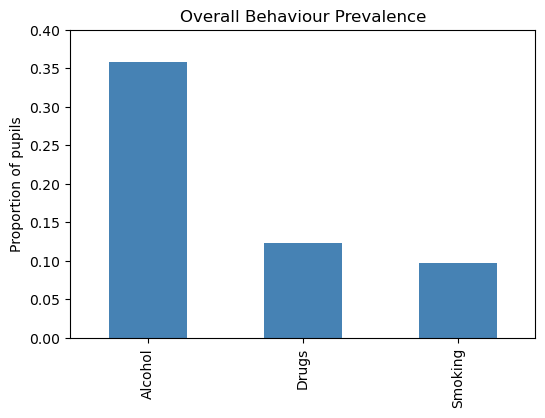


Behaviour prevalence by gender:


,Smoking,Alcohol,Drugs
gender_label,,,
Female,0.098518,0.371840,0.115664
Male,0.084804,0.333383,0.117410
Other,0.274390,0.518293,0.335366
Prefer not to say,0.176190,0.419048,0.185714


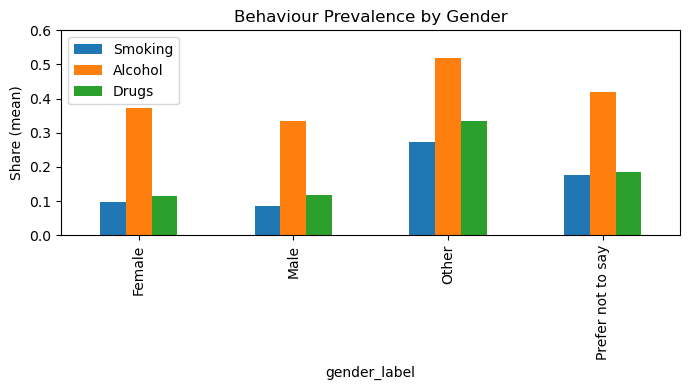

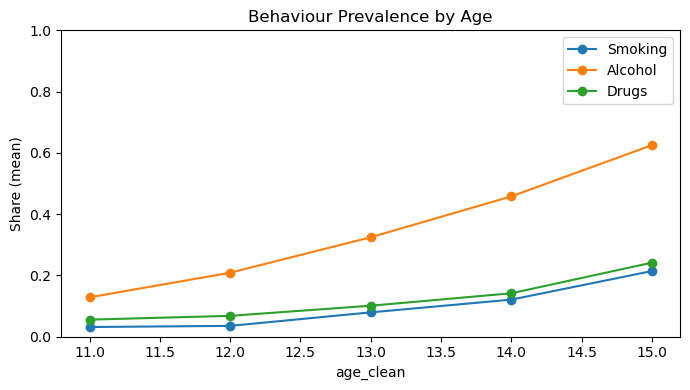

In [11]:
beh_cols = [c for c in ["Smoking", "Alcohol", "Drugs"] if c in pupil_clean.columns]

# --- Overall prevalence ---
prev_overall = pupil_clean[beh_cols].mean()
print("\nOverall behaviour prevalence (share of '1's):")
display(prev_overall)

plt.figure(figsize=(6,4))
prev_overall.sort_values(ascending=False).plot(kind="bar", color = "steelblue")
plt.title("Overall Behaviour Prevalence")
plt.ylabel("Proportion of pupils")
plt.ylim(0,0.4)
plt.show()

# --- By gender ---
if "gender_label" in pupil_clean:
    prev_gender = pupil_clean.groupby("gender_label")[beh_cols].mean()
    print("\nBehaviour prevalence by gender:")
    display(prev_gender)

    prev_gender.plot(kind="bar", figsize=(7,4))
    plt.title("Behaviour Prevalence by Gender")
    plt.ylabel("Share (mean)")
    plt.ylim(0,0.60)
    plt.tight_layout()
    plt.show()


# --- By age ---
prev_age = pupil_clean.groupby("age_clean")[beh_cols].mean()
prev_age.plot(marker="o", figsize=(7,4))
plt.title("Behaviour Prevalence by Age")
plt.ylabel("Share (mean)")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

### Behavioural prevalence by Ethnicity

<Figure size 1000x500 with 0 Axes>

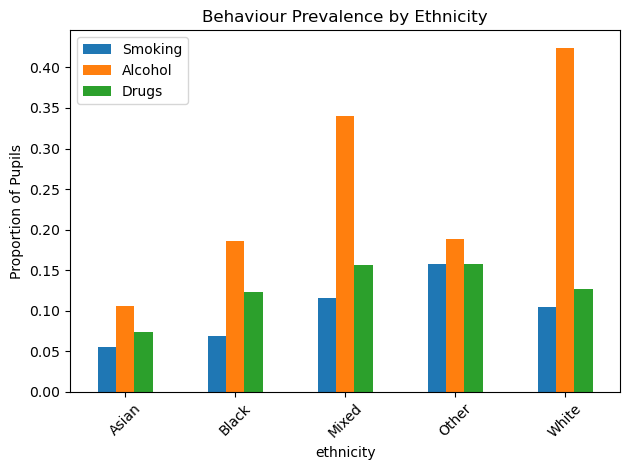

gender_label,Female,Male,Other,Prefer not to say
ethnicity,,,,
Asian,839,820,29,28
Black,532,551,34,13
Mixed,462,348,21,14
Other,112,101,9,6
White,4937,4866,235,149


In [12]:
beh_cols = ["Smoking", "Alcohol", "Drugs"]

prev_ethnicity = pupil_clean.groupby("ethnicity")[beh_cols].mean()

plt.figure(figsize=(10,5))
prev_ethnicity.plot(kind="bar")
plt.title("Behaviour Prevalence by Ethnicity")
plt.ylabel("Proportion of Pupils")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
pd.crosstab(pupil_clean["ethnicity"], pupil_clean["gender_label"])


##### 7C REGIONAL COMPARISONS


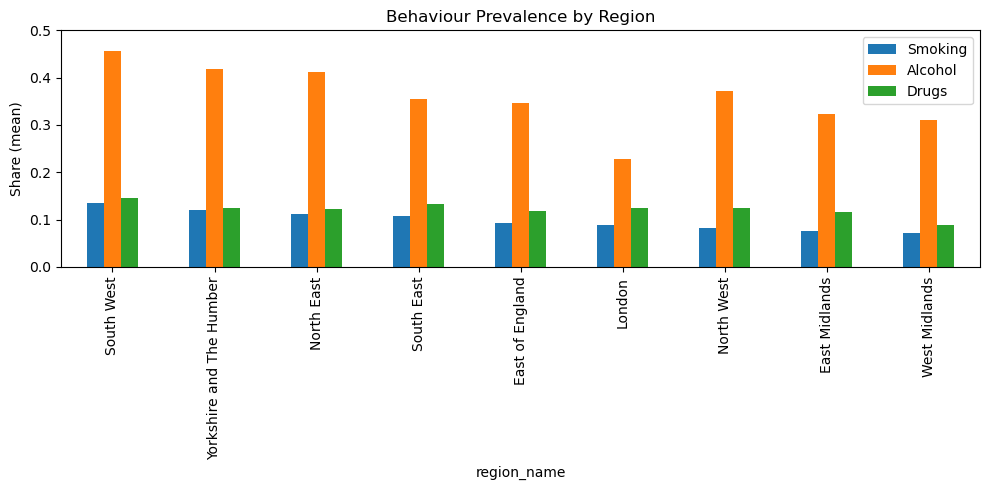

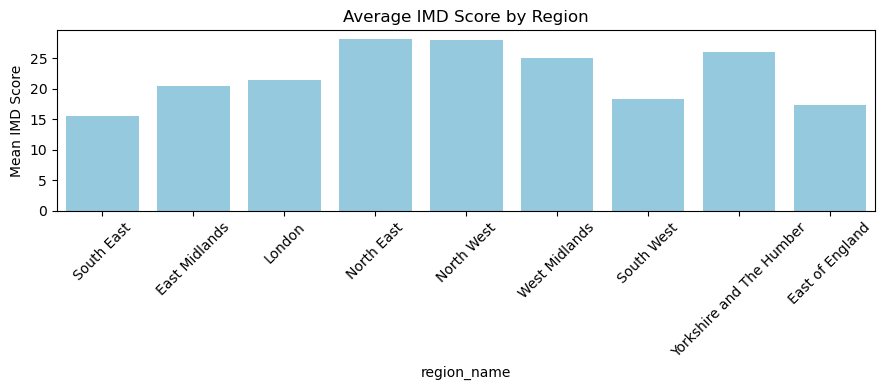

In [13]:
# --- Behaviour prevalence by region ---
prev_region = pupil_clean.groupby("region_name")[beh_cols].mean().sort_values(by="Smoking", ascending=False)
prev_region.plot(kind="bar", figsize=(10,5))
plt.title("Behaviour Prevalence by Region")
plt.ylabel("Share (mean)")
plt.ylim(0,0.5)
plt.tight_layout()
plt.show()

# --- IMD score by region ---
plt.figure(figsize=(9,4))
sns.barplot(data=pupil_enriched.drop_duplicates("region_name"),
x="region_name", y="imd_score", color="skyblue")
plt.xticks(rotation=45)
plt.title("Average IMD Score by Region")
plt.ylabel("Mean IMD Score")
plt.tight_layout()
plt.show()

##### 7D REGIONAL IMD  VS BEHAVIOURS

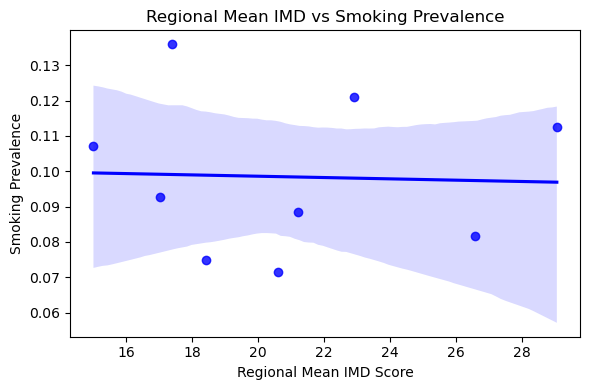

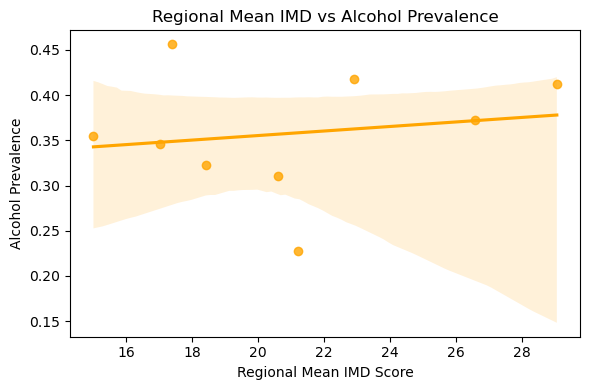

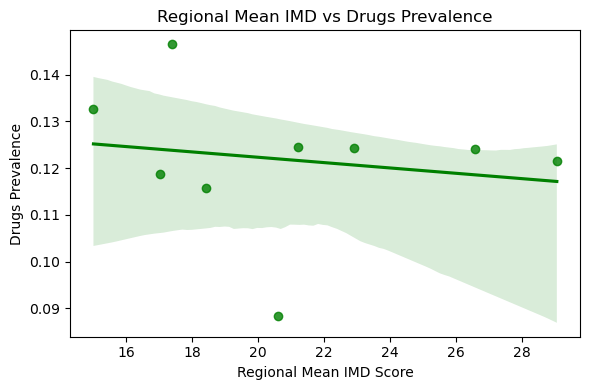

In [14]:
for col, color in zip(["Smoking", "Alcohol", "Drugs",], ["blue", "orange", "green"]):
    plt.figure(figsize=(6,4))
    sns.regplot(
        data=region_means,
        x="regional_mean_imd",
        y=col,
        marker="o",
        color=color
    )
    plt.title(f"Regional Mean IMD vs {col} Prevalence")
    plt.xlabel("Regional Mean IMD Score")
    plt.ylabel(f"{col} Prevalence")
    plt.tight_layout()
    plt.show()


##### 7E CORRELATION HEATMAP

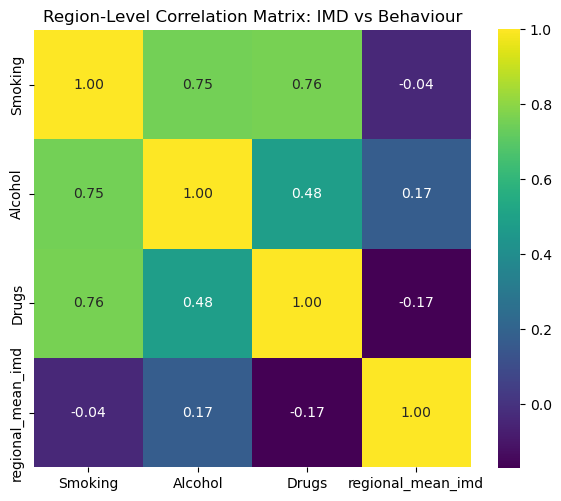

In [15]:
corr_region = region_means[["Smoking","Alcohol","Drugs", "regional_mean_imd"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_region, annot=True, cmap="viridis", fmt=".2f", square=True)
plt.title("Region-Level Correlation Matrix: IMD vs Behaviour")
plt.tight_layout()
plt.show()

# Modelling

### Data Preprocessing

In [16]:
#  Encode categorical variables
le_gender = LabelEncoder()
pupil_enriched["gender_code"] = le_gender.fit_transform(
    pupil_enriched["gender_label"].astype(str)
)

le_eth = LabelEncoder()
pupil_enriched["ethnicity_code"] = le_eth.fit_transform(
    pupil_enriched["ethnicity"].astype(str)
)

le_region = LabelEncoder()
pupil_enriched["region_code"] = le_region.fit_transform(
    pupil_enriched["region_name"].astype(str)
)

#  Features selection
imd_features = [
    "imd_score",
    "income_score",
    "employment_score",
    "education_score",
    "health_score",
    "crime_score",
    "housing_score",
    "living_env_score",
    "adult_skills_score",
    "idaci_score"
]

other_features = [
    "age_clean",
    "gender_code",
    "ethnicity_code",
    "region_code"
]

features = imd_features + other_features
target = "risk_behaviour"

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    pupil_enriched[features],
    pupil_enriched[target],
    test_size=0.25,
    random_state=42,
    stratify=pupil_enriched[target]
)

### XGBoost

In [18]:
# Auto-calc class weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=350,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

#  Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6694074284094131

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.68      0.71      2149
           1       0.57      0.66      0.61      1378

    accuracy                           0.67      3527
   macro avg       0.66      0.67      0.66      3527
weighted avg       0.68      0.67      0.67      3527


Confusion Matrix:
 [[1456  693]
 [ 473  905]]


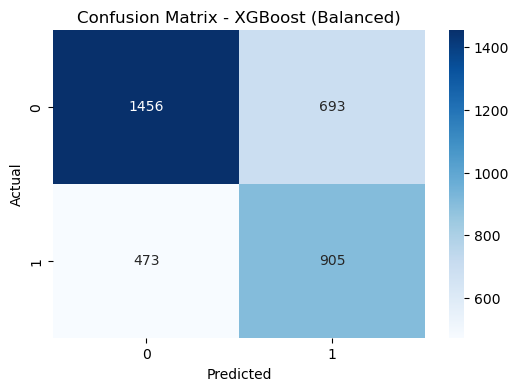

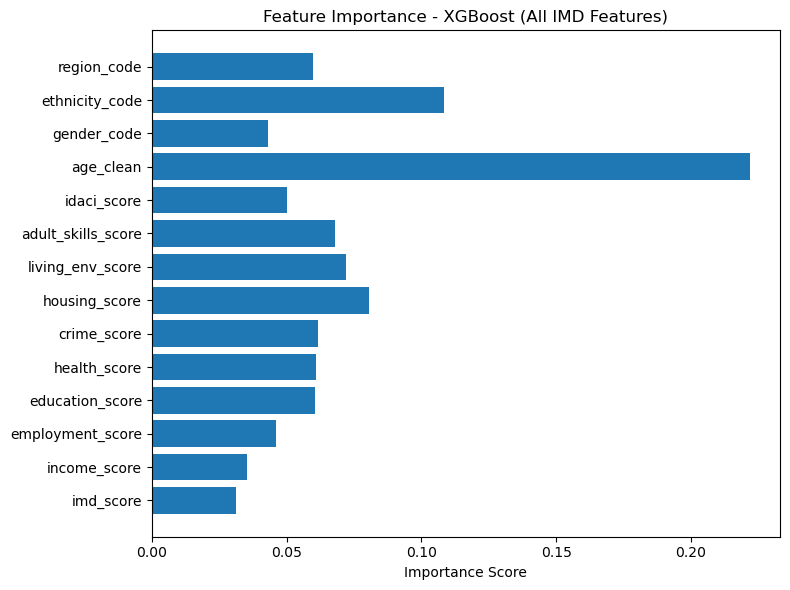

In [19]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Feature Importances
importance = model.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(features, importance)
plt.title("Feature Importance - XGBoost (All IMD Features)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

In [20]:
#Adjusting XG boost parameters to boost performance

from sklearn.model_selection import RandomizedSearchCV


xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
)

param_dist = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 300, 400, 500],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1]
}

random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=40, cv=3, scoring="f1_macro", verbose=1
)
random_search.fit(X_train, y_train)
    
print("Best parameters found by RandomizedSearchCV:", random_search.best_params_)
print("Best F1-macro score:", random_search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters found by RandomizedSearchCV: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best F1-macro score: 0.6791147808674182


In [21]:
#Training and Evaluating the Final XGBoost Model with the Tuned Parameters
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("\nAccuracy (Tuned XGBoost):", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report (Tuned XGBoost):\n", classification_report(y_test, y_pred_tuned))


Accuracy (Tuned XGBoost): 0.6858519988658917

Classification Report (Tuned XGBoost):
               precision    recall  f1-score   support

           0       0.77      0.70      0.73      2149
           1       0.59      0.67      0.62      1378

    accuracy                           0.69      3527
   macro avg       0.68      0.68      0.68      3527
weighted avg       0.70      0.69      0.69      3527



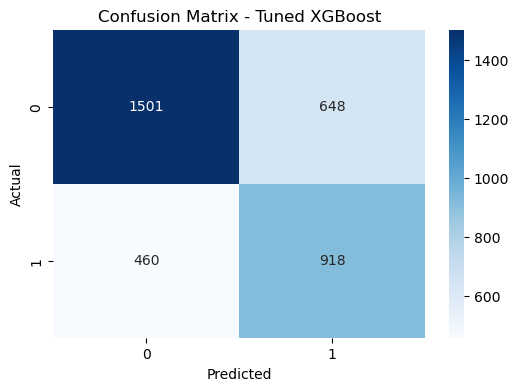

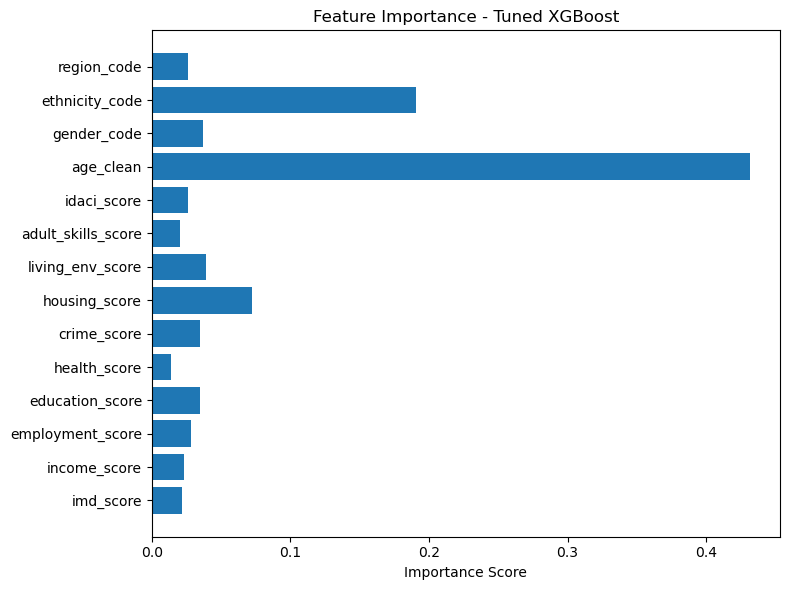

In [22]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importances
importance_tuned = best_model.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X_train.columns, importance_tuned)
plt.title("Feature Importance - Tuned XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### LOGISTIC REGRESSION MODEL


 LOGISTIC REGRESSION RESULTS
Accuracy: 0.658

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.62      0.69      2149
           1       0.55      0.72      0.62      1378

    accuracy                           0.66      3527
   macro avg       0.66      0.67      0.65      3527
weighted avg       0.69      0.66      0.66      3527


Confusion Matrix:
 [[1333  816]
 [ 390  988]]


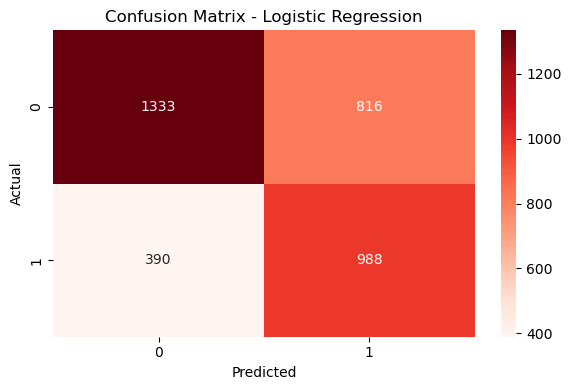

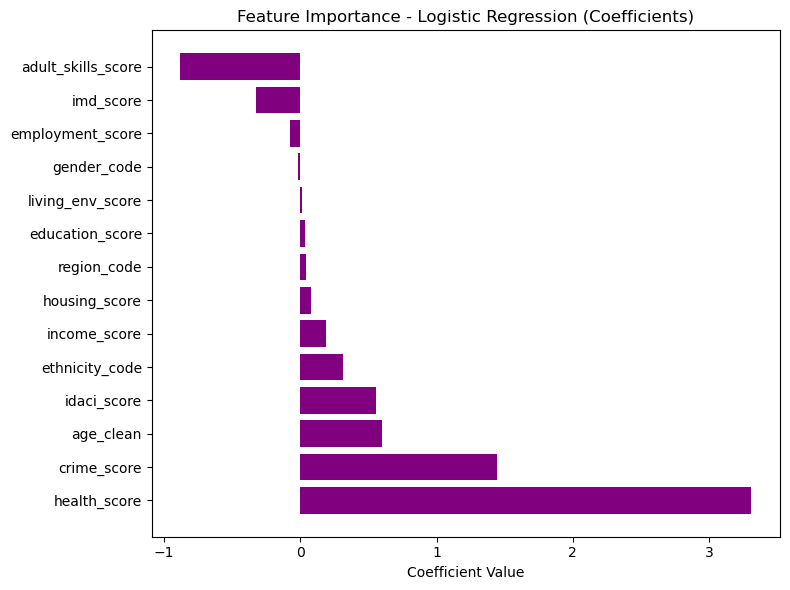

In [23]:
log_model = LogisticRegression(
    max_iter=500,
    solver='liblinear', 
    class_weight='balanced'  
)

# Fit model
log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Evaluation
print(" LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# Coefficient Importance

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
plt .barh(coef_df["Feature"], coef_df["Coefficient"], color="purple")
plt.title("Feature Importance - Logistic Regression (Coefficients)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

### Hyperparameter tuning for Logistic regression

In [24]:
param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 5, 10, 50],
    "solver": ["liblinear"],   
    "class_weight": ["balanced", None]
}

# Base model
log_reg = LogisticRegression(max_iter=500, random_state=42)

# Grid Search
grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit using training data
grid.fit(X_train, y_train)

print(" BEST LOGISTIC REGRESSION PARAMS")
print(grid.best_params_)

# Best model
best_log_reg = grid.best_estimator_

# EVALUATE TUNED LOGISTIC REGRESSION
y_pred_tuned = best_log_reg.predict(X_test)

print(" TUNED LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

 BEST LOGISTIC REGRESSION PARAMS
{'C': 50, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
 TUNED LOGISTIC REGRESSION RESULTS
Accuracy: 0.702

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.84      0.77      2149
           1       0.66      0.49      0.56      1378

    accuracy                           0.70      3527
   macro avg       0.69      0.66      0.67      3527
weighted avg       0.70      0.70      0.69      3527



### Comparison of models

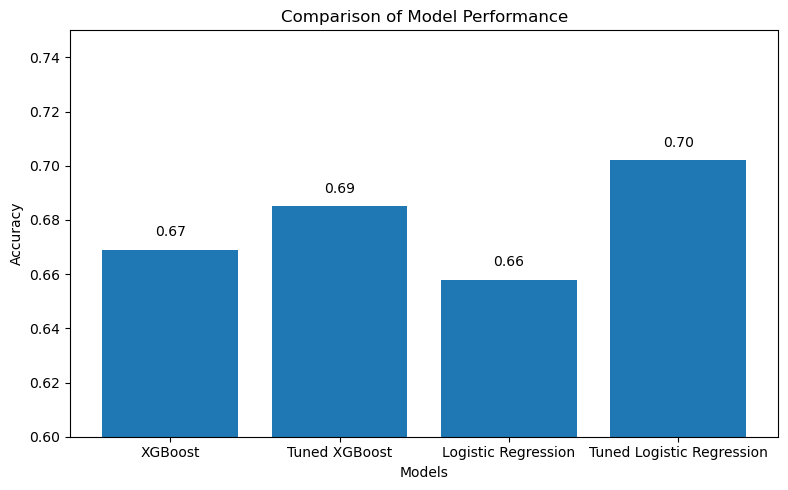

In [25]:

models = [
        'XGBoost',
    'Tuned XGBoost',
    'Logistic Regression',
    'Tuned Logistic Regression'
]

accuracy = [0.669, 0.685, 0.658, 0.702]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Performance')
plt.ylim(0.6, 0.75)
plt.tight_layout()

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.show()
